In [74]:
import numpy as np

import batoid
from batoid_rubin import LSSTBuilder
from galsim.zernike import zernikeRotMatrix

from lsst.ts.ofc import OFCData, StateEstimator

import matplotlib.pyplot as plt
from lsst.summit.utils import (
    ConsDbClient, 
    getBandpassSeeingCorrection, 
    getAirmassSeeingCorrection,
    makeDefaultButler
)
import pandas as pd
from lsst.daf.butler import Butler
from lsst.ts.aos.analysis import ofcUtils
from lsst_efd_client import EfdClient
from tqdm import tqdm as tqdm
%matplotlib widget

In [87]:
ofc_data_config_dir_path = '/home/gmegias/notebooks/lsst-ts/ts_config_mttcs/MTAOS/v8/ofc/'
ofc_data = OFCData(
    "lsst", 
    config_dir=ofc_data_config_dir_path
)
corner_rafts = [
    "R00", "R40",  # As they are laid out on the sky at RTP=0
    "R04", "R44",
]
corner_dets = [  # extra-focal
    191, 195, 
    199, 203,
]
corner_detnames = [  # extra-focal
    "R00_SW0", "R04_SW0",
    "R40_SW0", "R44_SW0",
]
field_angles_CCS = [
    ofc_data.sample_points[det] for det in corner_detnames
]

In [76]:
def parse_dof_str(dof_str):
    """Turn '0-4,10-14' into [0,1,2,3,4,10,11,12,13,14] for example...
    """
    dof_str = dof_str.strip()
    use_dof = []
    for part in dof_str.split(","):
        if "-" in part:
            start, end = [int(p) for p in part.split("-")]
            use_dof.extend(range(start, end + 1))
        else:
            use_dof.append(int(part))
    use_dof = np.sort(use_dof)
    return use_dof

In [88]:
def get_state(zk_ccs, rtp, use_dof, nkeep, band):
    ofc_data = OFCData(
        "lsst", 
        config_dir=ofc_data_config_dir_path
    )
    if isinstance(use_dof, str):
        use_dof = parse_dof_str(use_dof)

    new_comp_dof_idx = dict(
        m2HexPos=np.full(5, False, dtype=bool),
        camHexPos=np.full(5, False, dtype=bool),
        M1M3Bend=np.full(20, False, dtype=bool),
        M2Bend=np.full(20, False, dtype=bool),
    )
    for idof in use_dof:
        if idof < 5:
            new_comp_dof_idx["m2HexPos"][idof] = True
        elif 5 <= idof < 10:
            new_comp_dof_idx["camHexPos"][idof-5] = True
        elif 10 <= idof < 30:
            new_comp_dof_idx["M1M3Bend"][idof-10] = True
        elif 30 <= idof < 50:
            new_comp_dof_idx["M2Bend"][idof-30] = True

    ofc_data.comp_dof_idx = new_comp_dof_idx
    ofc_data.controller["truncation_index"] = nkeep
    state_estimator = StateEstimator(ofc_data)
        
    return state_estimator.dof_state(
        band.upper(),
        zk_ccs,
        corner_detnames,
        rtp,
    )

In [90]:
seqs_list = np.arange(279, 323)
day = 20250919

butler = Butler('LSSTCam', instrument='LSSTCam', collections=['LSSTCam/runs/quickLook'])
efd_client = EfdClient('summit_efd')
fetcher = ofcUtils.AOSFetcher(butler, efd_client, config_dir=ofc_data_config_dir_path)
query = f'''
    SELECT 
    e.seq_num AS seq,
    e.band,
    q.physical_rotator_angle,
    visit1.altitude,
    e.obs_end,
    e.obs_start
    FROM
    cdb_lsstcam.visit1 AS visit1,
    cdb_lsstcam.visit1_quicklook AS q,
    cdb_lsstcam.exposure AS e
    WHERE 
    visit1.visit_id = q.visit_id 
    AND visit1.visit_id = e.exposure_id
    AND (e.img_type = 'science' or e.img_type = 'acq') 
    AND (e.seq_num BETWEEN {np.min(seqs_list)} AND {np.min(seqs_list) - 1})
    AND (e.day_obs = {day})
'''
cdb_client = ConsDbClient('http://consdb-pq.consdb:8080/consdb')
cdb_table = cdb_client.query(query).to_pandas()
rots_by_seq = (
    cdb_table["physical_rotator_angle"]
    .round()        # rounds to the nearest integer
    .astype(int)    # make sure it’s integer type
)
el_by_seq = (
    cdb_table["altitude"]
    .round()
    .astype(int)
)

In [83]:
use_dof = parse_dof_str("5-9")
nkeep = len(use_dof)

states_array = []
for index in tqdm(range(len(rots_by_seq))):
    zernikes, zernike_array, noll_indices, sensor_names = fetcher.get_zernikes(int(f"{int(day)}{str(seqs_list[index]).zfill(5)}"))
    state = get_state(
        zernike_array,
        rtp=rots_by_seq.values[index],
        use_dof=use_dof,
        nkeep=nkeep,
        band=cdb_table["band"][index]
    )

    states_array.append(-state)

states_array = np.array(states_array)

100%|██████████| 44/44 [02:27<00:00,  3.35s/it]


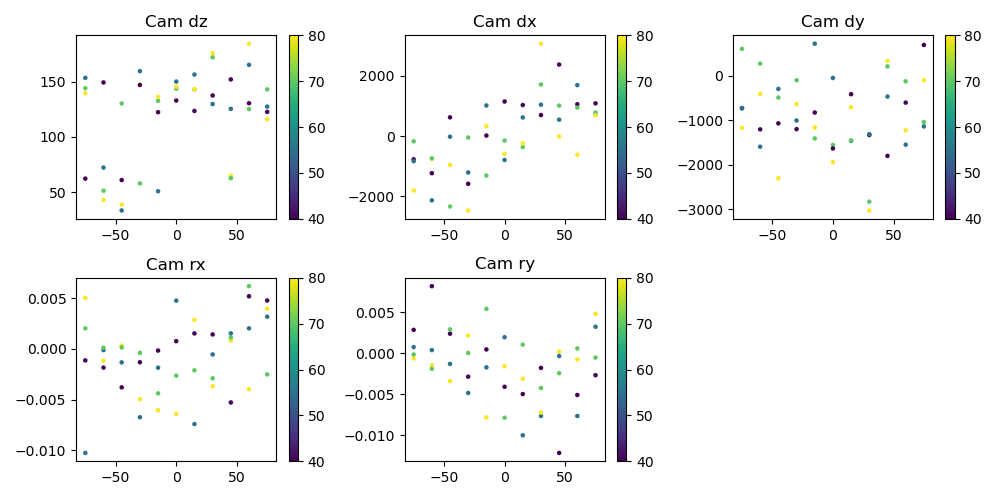

In [84]:
labels = ['Cam dz','Cam dx', 'Cam dy',  'Cam rx', 'Cam ry']
rots = np.linspace(min(rots_by_seq.values), max(rots_by_seq.values), 100)
plt.figure(figsize = (10, 5))
for i, dof in enumerate(use_dof):
    plt.subplot(2, 3, i + 1)
    plt.scatter(rots_by_seq.values, -states_array[:, i], c=el_by_seq.values, s=5, label='OFC')
    plt.colorbar()
    plt.title(labels[i])

plt.tight_layout()

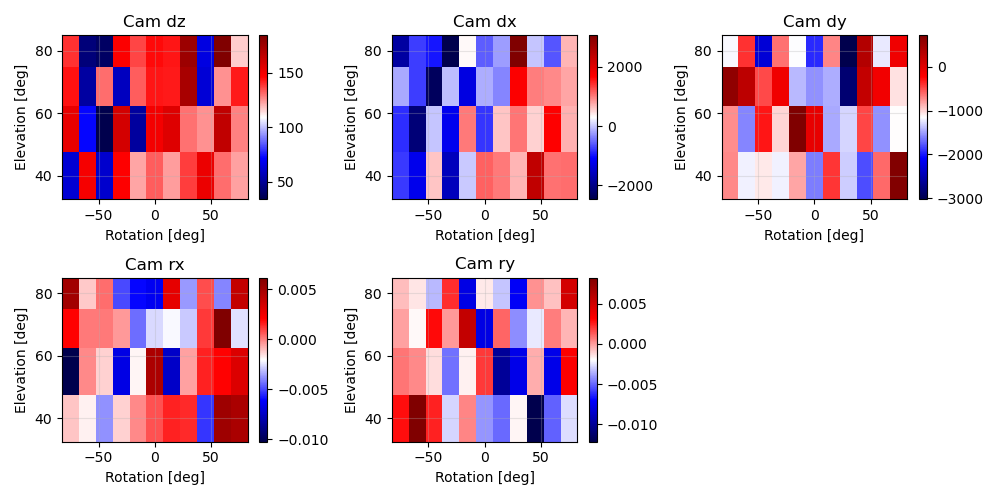

In [86]:
plt.figure(figsize=(10, 5))
for i, dof in enumerate(use_dof):
    ax = plt.subplot(2, 3, i + 1)

    # pivot the data so pcolormesh can use a rectangular grid
    df_plot = pd.DataFrame({
        "rot": rots_by_seq.values,
        "el": el_by_seq.values,
        "val": -states_array[:, i]
    })
    grid = df_plot.pivot(index="el", columns="rot", values="val")

    surf = ax.pcolormesh(grid.columns, grid.index, grid.values,
                         shading="auto", cmap="seismic")
    plt.colorbar(surf, ax=ax)
    ax.set_title(labels[i])
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()